Initial Position for ETH/USD LP (Range: 4900.0-5100.0):
Liquidity (L): 7035.53
ETH used: 0.9803 (refund: 0.0197)
USD used: 5000.00 (refund: 0.00)
Initial value: 9901.47 USD

Range width: 4.00%
Concentration multiplier: 25.0x
Estimated effective APR (if price stays in-range): 275.00%
(Note: Real APR depends on volume, time in-range, and IL; this is an approximation.)

Position Value Over Price Scenarios:
| {asset_name} Price (USD) | Position Value (USD) | Hold Value (USD) | % Impermanent Loss |
|--------------------------|----------------------|------------------|--------------------|
|                   4000 |              7961.79 |          8921.18 |             -10.75% |
|                   4500 |              8957.01 |          9411.33 |              -4.83% |
|                   4900 |              9753.19 |          9803.44 |              -0.51% |
|                   5000 |              9901.47 |          9901.47 |               0.00% |
|                   5100 |              9950.

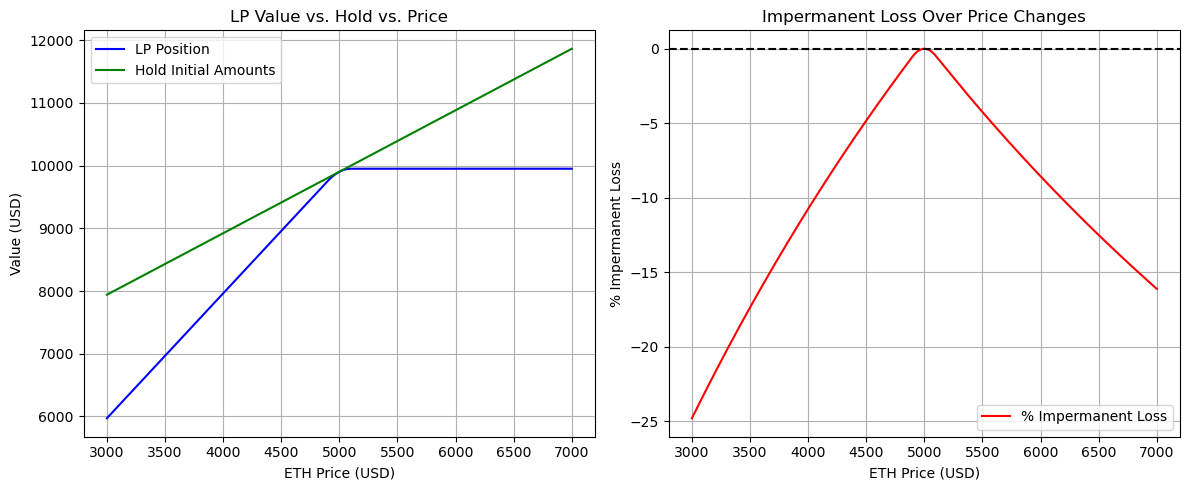

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

def calculate_lp_position(current_price, token_amount, usd_amount, lower_price, upper_price):
    """
    Calculate liquidity L and used amounts for a V3-style concentrated LP deposit.
    Returns: L, token_used, usd_used, token_refund, usd_refund
    """
    sqrt_p = math.sqrt(current_price)
    sqrt_pa = math.sqrt(lower_price)
    sqrt_pb = math.sqrt(upper_price)
    
    # Assume current price is within range (sqrt_pa < sqrt_p < sqrt_pb)
    if sqrt_p <= sqrt_pa or sqrt_p >= sqrt_pb:
        raise ValueError("Current price must be within the range.")
    
    # Max L from token (asset) deposit
    inv_p = 1 / sqrt_p
    inv_pb = 1 / sqrt_pb
    l_token = token_amount / (inv_p - inv_pb)
    
    # Max L from USD deposit
    l_usd = usd_amount / (sqrt_p - sqrt_pa)
    
    # Use the minimum L (binding constraint)
    l = min(l_token, l_usd)
    
    # Actual amounts used
    token_used = l * (inv_p - inv_pb)
    usd_used = l * (sqrt_p - sqrt_pa)
    
    # Refunds (excess)
    token_refund = token_amount - token_used
    usd_refund = usd_amount - usd_used
    
    return l, token_used, usd_used, token_refund, usd_refund

def position_value(l, pf, lower_price, upper_price):
    """
    Compute position USD value at future price pf.
    """
    sqrt_pf = math.sqrt(pf)
    sqrt_pa = math.sqrt(lower_price)
    sqrt_pb = math.sqrt(upper_price)
    
    if sqrt_pf <= sqrt_pa:
        # Fully in token (asset)
        token = l * (1 / sqrt_pa - 1 / sqrt_pb)
        usd = 0.0
    elif sqrt_pf >= sqrt_pb:
        # Fully in USD
        token = 0.0
        usd = l * (sqrt_pb - sqrt_pa)
    else:
        # Mixed
        token = l * (1 / sqrt_pf - 1 / sqrt_pb)
        usd = l * (sqrt_pf - sqrt_pa)
    
    value = usd + token * pf
    return value

def estimate_effective_apr(pool_apr, current_price, lower_price, upper_price):
    """
    Estimate effective APR for concentrated position.
    Approximation: Scales pool APR inversely with range width % (assumes price stays in-range).
    """
    width_pct = (upper_price - lower_price) / current_price * 100
    multiplier = 100 / width_pct
    effective_apr = pool_apr * multiplier
    return effective_apr, width_pct, multiplier

# Example usage (customize these)
asset_name = "ETH"  # e.g., "BTC" for generality
current_price = 5000.0
token_amount = 1.0
usd_amount = 5000.0
lower_price = 4900.0
upper_price = 5100.0

# Base pool APR (from DeFiLlama, Sep 2025 data for ETH-USDC 0.05% pool; update as needed)
pool_apr = 0.11  # 11%

# Step 1: Calculate position
l, token_used, usd_used, token_refund, usd_refund = calculate_lp_position(
    current_price, token_amount, usd_amount, lower_price, upper_price
)

print(f"Initial Position for {asset_name}/USD LP (Range: {lower_price}-{upper_price}):")
print(f"Liquidity (L): {l:.2f}")
print(f"{asset_name} used: {token_used:.4f} (refund: {token_refund:.4f})")
print(f"USD used: {usd_used:.2f} (refund: {usd_refund:.2f})")
print(f"Initial value: {usd_used + token_used * current_price:.2f} USD")

# Step 2: Estimate APR
eff_apr, width_pct, multiplier = estimate_effective_apr(pool_apr, current_price, lower_price, upper_price)
print(f"\nRange width: {width_pct:.2f}%")
print(f"Concentration multiplier: {multiplier:.1f}x")
print(f"Estimated effective APR (if price stays in-range): {eff_apr * 100:.2f}%")
print("(Note: Real APR depends on volume, time in-range, and IL; this is an approximation.)")

# Step 3: Table of values at key prices
key_prices = [4000, 4500, 4900, 5000, 5100, 5500, 6000]
print("\nPosition Value Over Price Scenarios:")
print("| {asset_name} Price (USD) | Position Value (USD) | Hold Value (USD) | % Impermanent Loss |")
print("|--------------------------|----------------------|------------------|--------------------|")
for p in key_prices:
    pos_val = position_value(l, p, lower_price, upper_price)
    hold_val = usd_used + token_used * p
    il_pct = (pos_val - hold_val) / hold_val * 100 if hold_val > 0 else 0
    print(f"| {p:>22} | {pos_val:>20.2f} | {hold_val:>16.2f} | {il_pct:>18.2f}% |")

# Step 4: Plots
prices = np.linspace(3000, 7000, 200)
pos_values = np.array([position_value(l, p, lower_price, upper_price) for p in prices])
hold_values = usd_used + token_used * prices
il_pcts = (pos_values - hold_values) / hold_values * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Values vs Price
ax1.plot(prices, pos_values, label='LP Position', color='blue')
ax1.plot(prices, hold_values, label='Hold Initial Amounts', color='green')
ax1.set_xlabel(f'{asset_name} Price (USD)')
ax1.set_ylabel('Value (USD)')
ax1.set_title('LP Value vs. Hold vs. Price')
ax1.legend()
ax1.grid(True)

# Plot 2: Impermanent Loss % vs Price
ax2.plot(prices, il_pcts, label='% Impermanent Loss', color='red')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.set_xlabel(f'{asset_name} Price (USD)')
ax2.set_ylabel('% Impermanent Loss')
ax2.set_title('Impermanent Loss Over Price Changes')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()